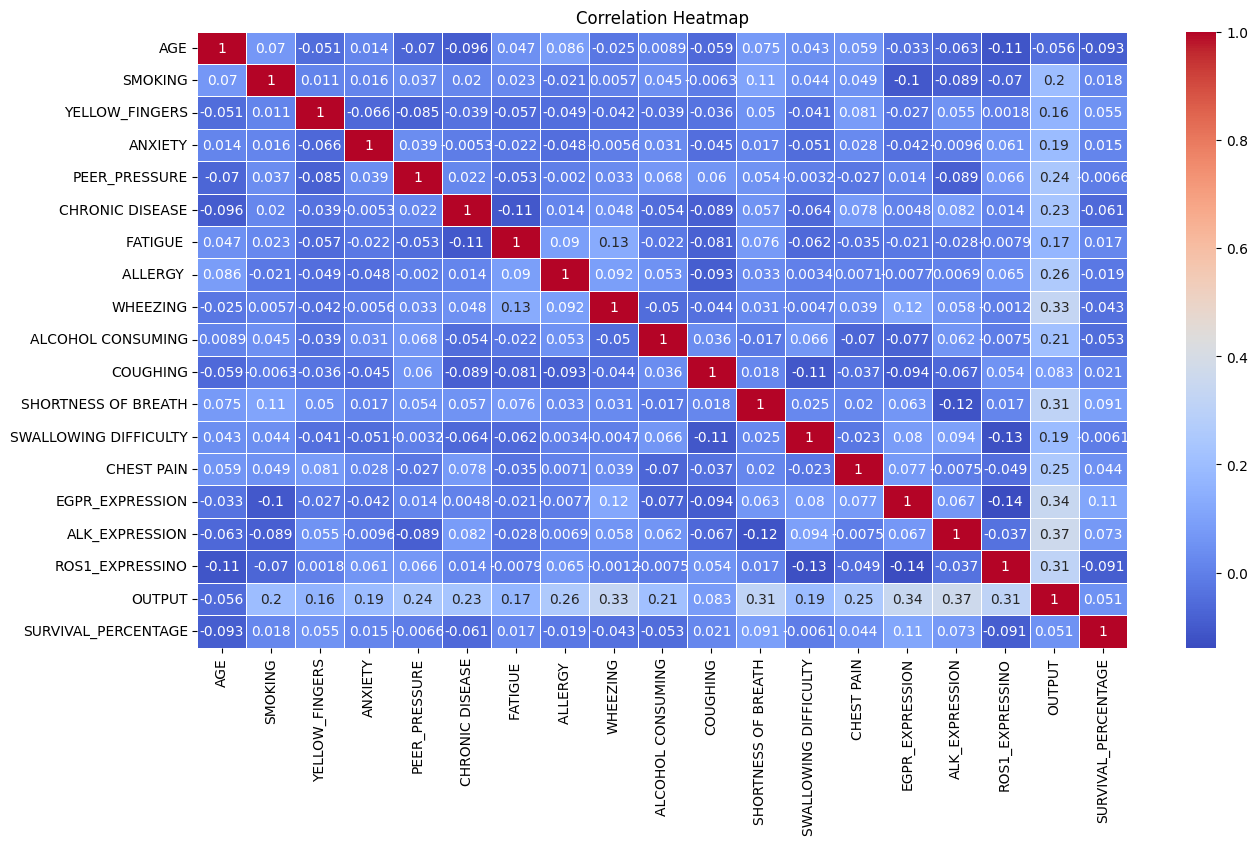

In [12]:
import pandas as pd 
data = pd.read_csv(r"C:\Users\aarya\Desktop\Specialization AIML\Projects\lung_cancer.csv")
import seaborn as sns
import matplotlib.pyplot as plt
data = data.drop(['GENDER', 'LUNG_CANCER'], axis=1)
corr_matrix = data.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.7)
plt.title('Correlation Heatmap')
plt.show()

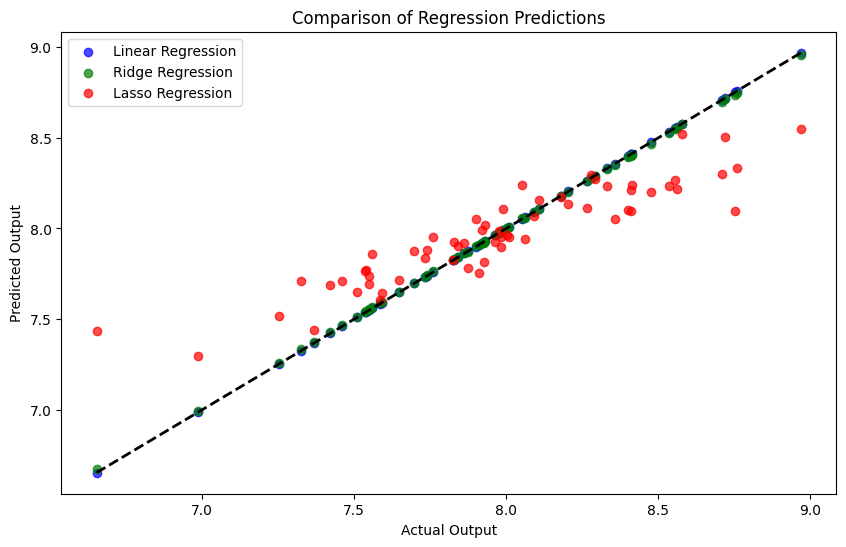

In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Assuming 'data' contains your dataset
X = data.drop(['OUTPUT', 'SURVIVAL_PERCENTAGE'], axis=1)
y = data['OUTPUT']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
linear_model = LinearRegression()
ridge_model = Ridge(alpha=10.0)
lasso_model = Lasso(alpha=0.1)

# Train models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Make predictions
linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

# Scatter plot to compare predictions
plt.figure(figsize=(10, 6))

plt.scatter(y_test, linear_pred, alpha=0.7, label='Linear Regression', color='blue')
plt.scatter(y_test, ridge_pred, alpha=0.7, label='Ridge Regression', color='green')
plt.scatter(y_test, lasso_pred, alpha=0.7, label='Lasso Regression', color='red')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Line of perfect fit
plt.xlabel('Actual Output')
plt.ylabel('Predicted Output')
plt.title('Comparison of Regression Predictions')
plt.legend()
plt.show()
